# Reducción de dimensiones

Como veremos a continuación, apliqué un conjunto de técnicas para reducir las dimensiones de mi conjunto de datos e intentar entender de mejor manera la estructura de mi dataset. Aplicamos PCA, t-SNE, UMAP y LDA. Los resultados mostraron que para la tarea de clusterizar géneros musicales (15 en nuestro caso), la complejidad nos juega en contra. Es realmente complicado separar los géneros con una técnica no supervisada y aplicando reducción de dimensiones. 

Hay mucho cruzamiento de géneros y no hay una clara separación entre ellos. Los resultados obtenidos nos indican que para esta tarea es necesario algo mucho más robusto para la clasificación. Sin embargo, puede ser que estos métodos nos ayuden como base para alimentar una red neuronal. En mi caso, no tomaré eso para el entrenamineto del modelo porque confío en que utilizando todas las features de maenera directa, un MLP puede resolver de buena manera el problema. Además, sí realicé una prueba utilizando como entrada los resultados de un PCA, pero no hubo un gran cambio en los resultados, así que preferí dejar las características sin reducción de dimensiones. 

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap # <-- Importación corregida y más robusta
import time


Datos preparados. Se procesarán 531 características numéricas.
Características escaladas exitosamente.
PCA aplicado. Reducción a 2 componentes completada.
Varianza explicada por Componente 1: 11.90%
Varianza explicada por Componente 2: 7.67%
Varianza total explicada por los 2 componentes: 19.57%
Gráfico de PCA guardado como 'pca_genre_visualization.png'


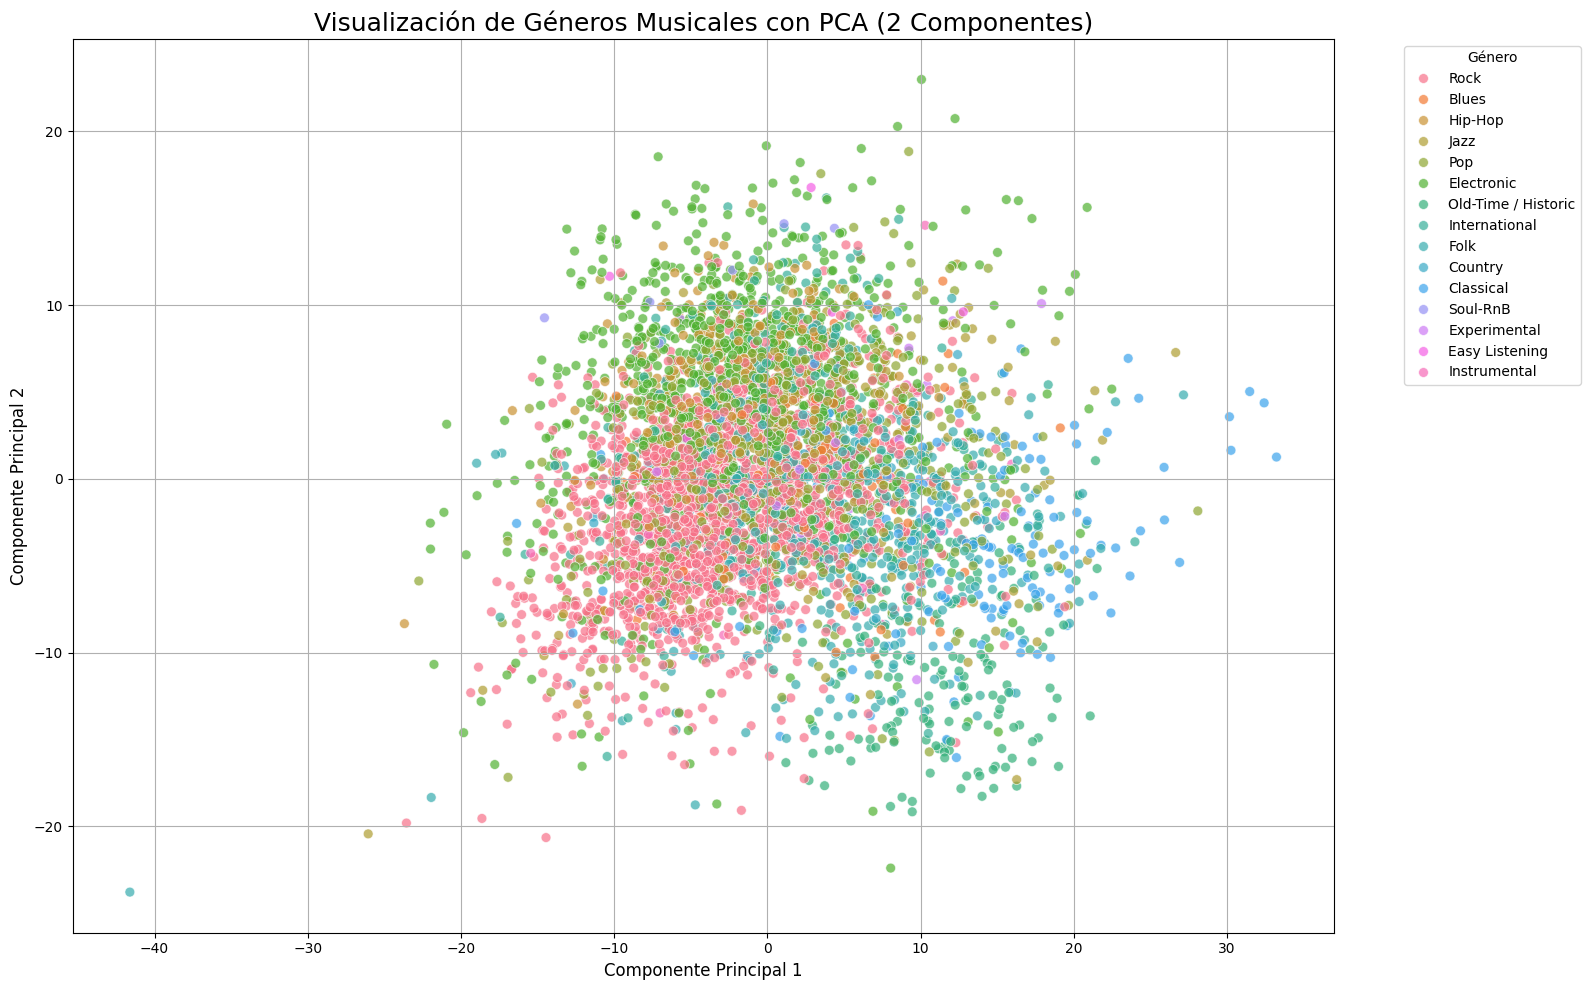

In [ ]:
try:
    # Cargar el dataset
    df_train = pd.read_csv('/home/cesar/Descargas/MIR-features-tarea01/fma_train_merged.csv')

    target = df_train['track.genre1']
    non_numeric_cols = df_train.select_dtypes(exclude=np.number).columns
    features_df = df_train.drop(columns=non_numeric_cols)
    if 'track_id' in features_df.columns:
        features_df = features_df.drop(columns=['track_id'])

    features_df.fillna(features_df.median(), inplace=True)
    
    print(f"Datos preparados. Se procesarán {features_df.shape[1]} características numéricas.")

    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features_df)
    print("Características escaladas exitosamente.")

    pca = PCA(n_components=2)
    principal_components = pca.fit_transform(features_scaled)
    print("PCA aplicado. Reducción a 2 componentes completada.")

    pca_df = pd.DataFrame(data=principal_components, columns=['Componente Principal 1', 'Componente Principal 2'])
    pca_df['genre'] = target
    
    explained_variance = pca.explained_variance_ratio_
    print(f"Varianza explicada por Componente 1: {explained_variance[0]:.2%}")
    print(f"Varianza explicada por Componente 2: {explained_variance[1]:.2%}")
    print(f"Varianza total explicada por los 2 componentes: {np.sum(explained_variance):.2%}")

    if len(pca_df) > 5000:
        plot_df = pca_df.sample(n=5000, random_state=42)
    else:
        plot_df = pca_df

    plt.figure(figsize=(16, 10))
    sns.scatterplot(
        x="Componente Principal 1", 
        y="Componente Principal 2",
        hue="genre",
        data=plot_df,
        alpha=0.7,
        s=50
    )

    plt.title('Visualización de Géneros Musicales con PCA (2 Componentes)', fontsize=18)
    plt.xlabel('Componente Principal 1', fontsize=12)
    plt.ylabel('Componente Principal 2', fontsize=12)
    plt.legend(title='Género', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('pca_genre_visualization.png')
    print("Gráfico de PCA guardado como 'pca_genre_visualization.png'")

except FileNotFoundError:
    print("Error: No se encontró el archivo 'fma_train_merged.csv'.")
except Exception as e:
    print(f"Ocurrió un error inesperado: {e}")

Aplicando t-SNE... Esto puede tardar unos minutos.
t-SNE completado en 7.62 segundos.
Gráfico de t-SNE guardado como 'tsne_genre_visualization.png'


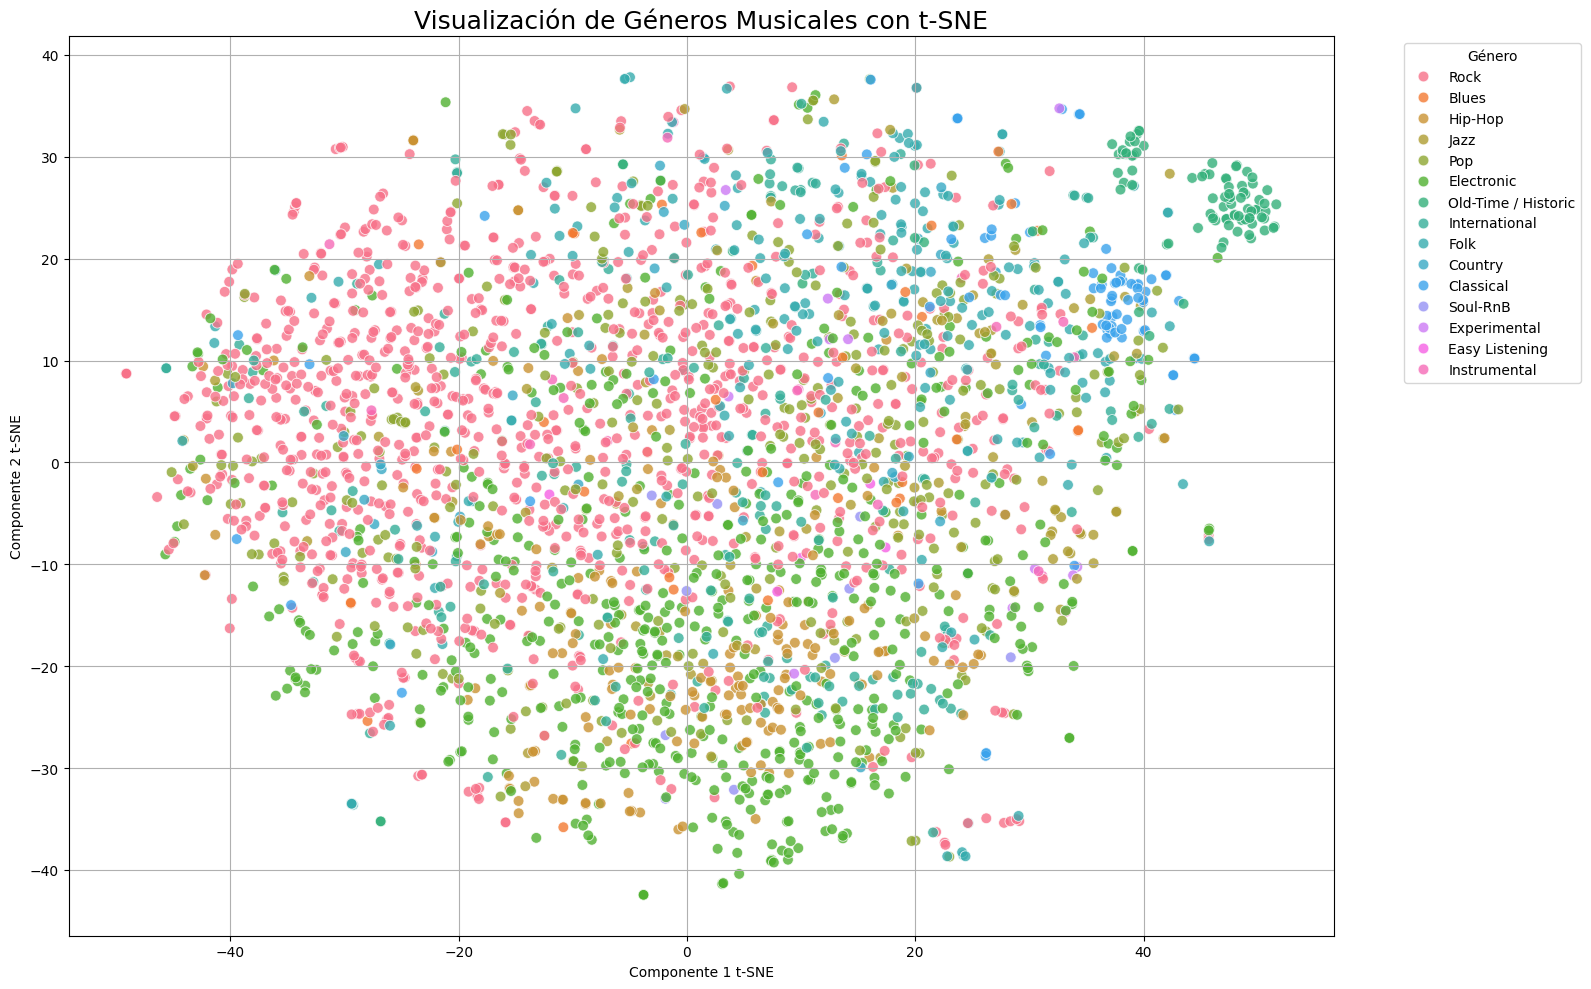

In [ ]:
try:
    df_train = pd.read_csv('/home/cesar/Descargas/MIR-features-tarea01/fma_train_merged.csv')

    target = df_train['track.genre1']
    features_df = df_train.select_dtypes(include=np.number).drop(columns=['track_id'])
    features_df.fillna(features_df.median(), inplace=True)
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features_df)
    
    n_samples = 3000
    np.random.seed(42)
    sample_indices = np.random.choice(features_scaled.shape[0], n_samples, replace=False)
    features_subset = features_scaled[sample_indices, :]
    target_subset = target.iloc[sample_indices]

    print("Aplicando t-SNE... Esto puede tardar unos minutos.")
    start_time = time.time()
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1)
    tsne_results = tsne.fit_transform(features_subset)
    end_time = time.time()
    print(f"t-SNE completado en {end_time - start_time:.2f} segundos.")

    tsne_df = pd.DataFrame(data=tsne_results, columns=['Componente 1 t-SNE', 'Componente 2 t-SNE'])
    tsne_df['genre'] = target_subset.values
    
    plt.figure(figsize=(16, 10))
    sns.scatterplot(
        x="Componente 1 t-SNE", y="Componente 2 t-SNE",
        hue="genre", data=tsne_df, alpha=0.8, s=60
    )
    plt.title('Visualización de Géneros Musicales con t-SNE', fontsize=18)
    plt.legend(title='Género', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('tsne_genre_visualization.png')
    print("Gráfico de t-SNE guardado como 'tsne_genre_visualization.png'")

except FileNotFoundError:
    print("Error: No se encontró el archivo 'fma_train_merged.csv'.")

Aplicando UMAP...


/home/cesar/miniconda3/envs/voyager/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP completado.
Gráfico UMAP mejorado guardado como 'umap_styled_visualization.png'


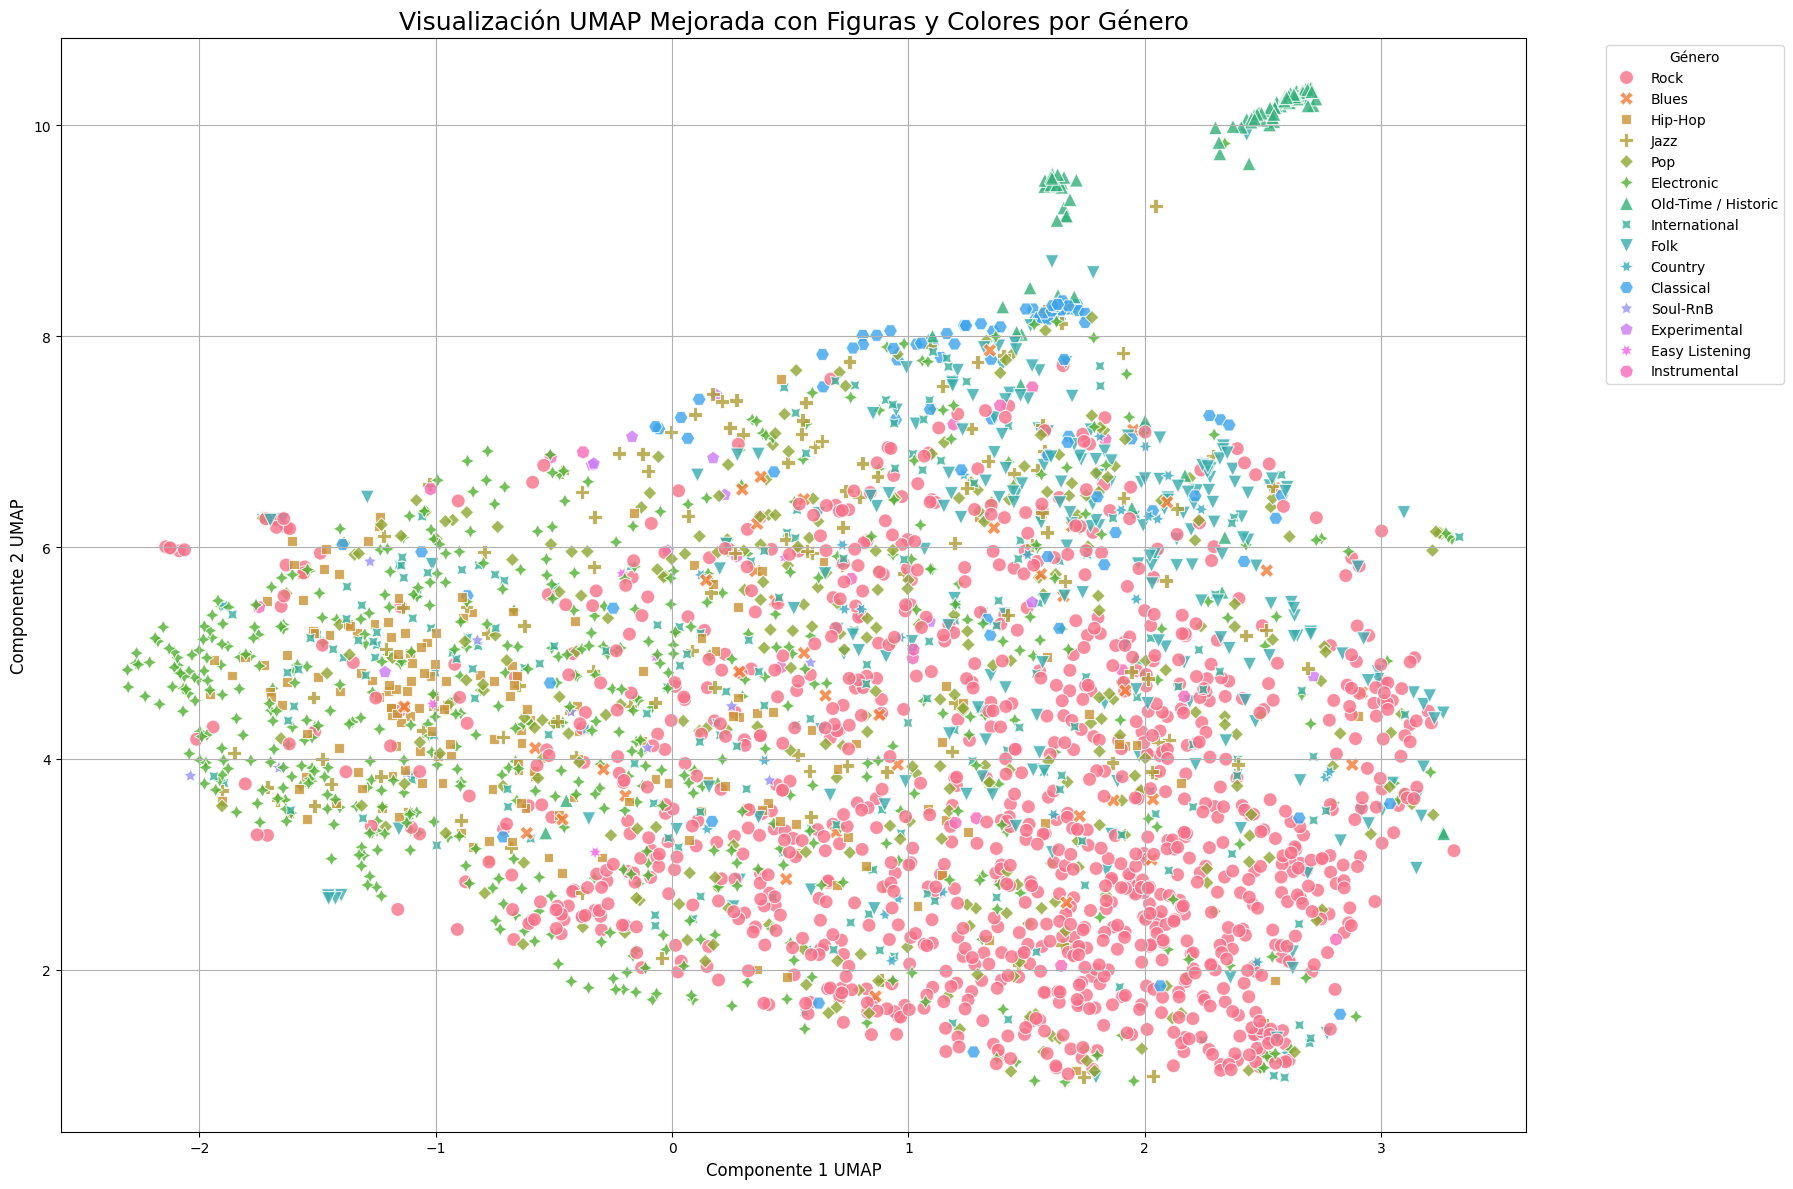

In [ ]:
try:
    df_train = pd.read_csv('/home/cesar/Descargas/MIR-features-tarea01/fma_train_merged.csv')

    target = df_train['track.genre1']
    features_df = df_train.select_dtypes(include=np.number).drop(columns=['track_id'])
    features_df.fillna(features_df.median(), inplace=True)
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features_df)
    
    n_samples = 3000
    np.random.seed(42)
    sample_indices = np.random.choice(features_scaled.shape[0], n_samples, replace=False)
    features_subset = features_scaled[sample_indices, :]
    target_subset = target.iloc[sample_indices]

    print("Aplicando UMAP...")
    umap_reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
    umap_results = umap_reducer.fit_transform(features_subset)
    print("UMAP completado.")

    umap_df = pd.DataFrame(data=umap_results, columns=['Componente 1 UMAP', 'Componente 2 UMAP'])
    umap_df['genre'] = target_subset.values
    
    plt.figure(figsize=(18, 12))
    sns.scatterplot(
        x="Componente 1 UMAP", 
        y="Componente 2 UMAP",
        hue="genre",      
        style="genre",    
        data=umap_df,
        alpha=0.8,
        s=100             
    )

    plt.title('Visualización UMAP Mejorada con Figuras y Colores por Género', fontsize=18)
    plt.xlabel('Componente 1 UMAP', fontsize=12)
    plt.ylabel('Componente 2 UMAP', fontsize=12)
    plt.legend(title='Género', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('umap_styled_visualization.png')
    print("Gráfico UMAP mejorado guardado como 'umap_styled_visualization.png'")

except FileNotFoundError:
    print("Error: No se encontró el archivo 'fma_train_merged.csv'.")
except Exception as e:
    print(f"Ocurrió un error inesperado: {e}")

Aplicando LDA...
LDA completado.
Gráfico LDA mejorado guardado como 'lda_styled_visualization.png'


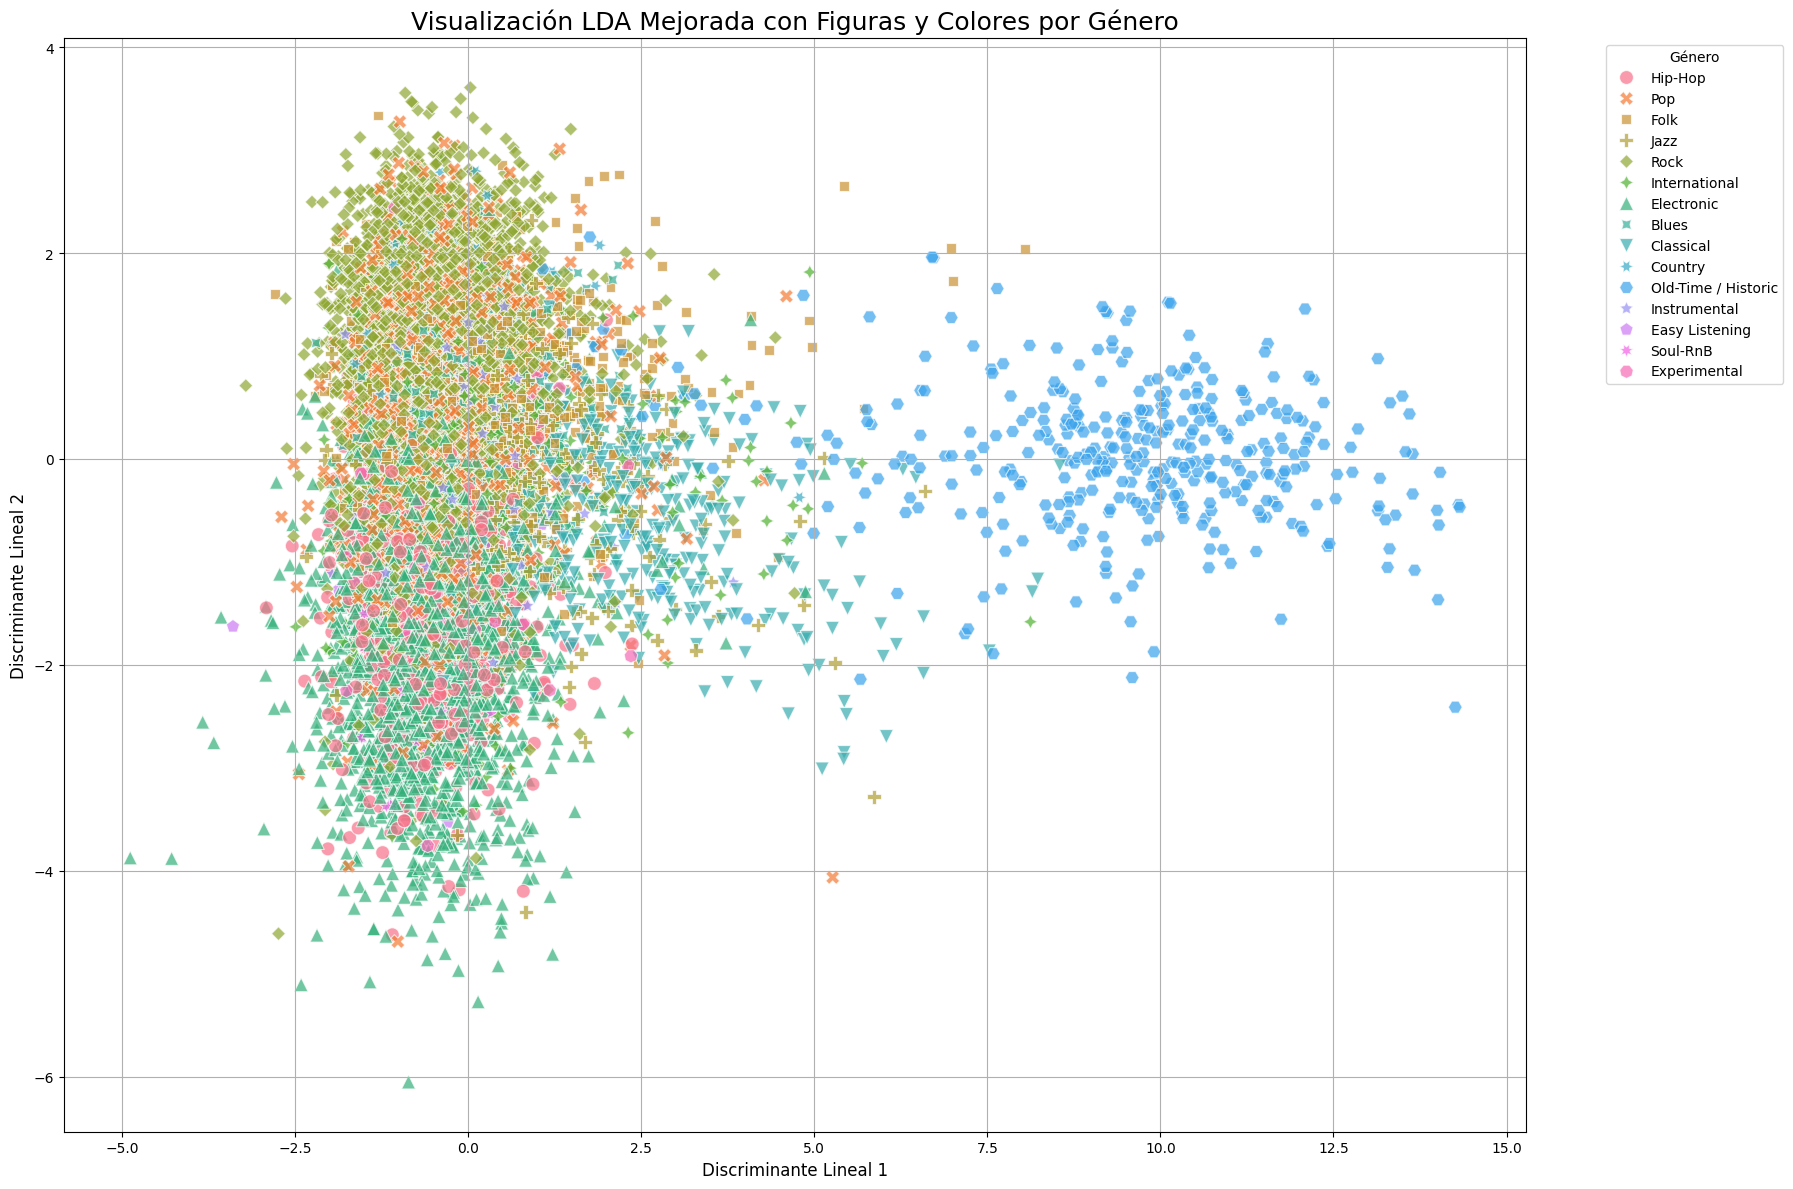

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

try:
    df_train = pd.read_csv('/home/cesar/Descargas/MIR-features-tarea01/fma_train_merged.csv')

    target_str = df_train['track.genre1']
    features_df = df_train.select_dtypes(include=np.number).drop(columns=['track_id'])
    features_df.fillna(features_df.median(), inplace=True)
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features_df)
    
    le = LabelEncoder()
    target_encoded = le.fit_transform(target_str)

    print("Aplicando LDA...")
    lda = LinearDiscriminantAnalysis(n_components=2)
    lda_results = lda.fit_transform(features_scaled, target_encoded)
    print("LDA completado.")

    lda_df = pd.DataFrame(data=lda_results, columns=['Componente Lineal 1', 'Componente Lineal 2'])
    lda_df['genre'] = target_str 

    plt.figure(figsize=(18, 12))
    sns.scatterplot(
        x="Componente Lineal 1", 
        y="Componente Lineal 2",
        hue="genre",      
        style="genre",    
        data=lda_df,
        alpha=0.7,
        s=100            
    )

    plt.title('Visualización LDA Mejorada con Figuras y Colores por Género', fontsize=18)
    plt.xlabel('Discriminante Lineal 1', fontsize=12)
    plt.ylabel('Discriminante Lineal 2', fontsize=12)
    plt.legend(title='Género', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    
    plt.savefig('lda_styled_visualization.png')
    print("Gráfico LDA mejorado guardado como 'lda_styled_visualization.png'")

except FileNotFoundError:
    print("Error: No se encontró el archivo 'fma_train_merged.csv'.")
except Exception as e:
    print(f"Ocurrió un error inesperado: {e}")